***1— Libraries Import***

***Project Summary:  
This project analyzed customer churn data to uncover retention patterns. Using Python libraries (Pandas, Seaborn, Matplotlib), exploratory data analysis and visualizations were performed on demographic, tenure, and contract features. The study revealed that senior citizens and short‑tenure customers are more likely to churn, while long‑term contracts significantly reduce churn risk. These insights suggest that targeted retention strategies, such as loyalty programs and contract upgrades, can improve customer lifetime value.***

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

***Insight: Imported all required libraries — Pandas for data handling, NumPy for numerical ops, Matplotlib & Seaborn for visualizations.***

***2— Data Load***

In [7]:
df = pd.read_csv("C:\\Users\\ayush\\Downloads\\Customer Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


***Insight: Dataset loaded successfully with 7,043 rows and 21 columns.***

***3— Basic Exploration***

In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [10]:
df.shape

(7043, 21)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


***Insight: TotalCharges is object type instead of float — needs fixing. All other dtypes look correct.***

***4— Data Cleaning: Fix TotalCharges***

In [12]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [13]:
df["TotalCharges"] = df["TotalCharges"].str.strip()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

***Insight: TotalCharges had blank strings for new customers (tenure = 0). Stripped spaces, converted to numeric, and filled NaN with 0 since no service has been billed yet.***

***5— Data Cleaning: Missing Values***

In [14]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

***Insight: All columns show 0 null values after fixing TotalCharges — dataset is clean.***

***6 — Data Cleaning: Duplicates***

In [15]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customerIDs:", df["customerID"].duplicated().sum())

Duplicate rows: 0
Duplicate customerIDs: 0


***Insight: No duplicate rows or customer IDs found — data integrity is confirmed.***

***7 — Data Cleaning: SeniorCitizen Convert***

In [16]:
def conv(value):
    if value == 1:
        return "Yes"
    else:
        return "No"

df["SeniorCitizen"] = df["SeniorCitizen"].apply(conv)
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,No,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,No,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,No,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,No,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,No,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


***Insight: SeniorCitizen was stored as 0/1 integer. Converted to Yes/No for better readability in charts.***

***8 — Overall Churn Distribution***

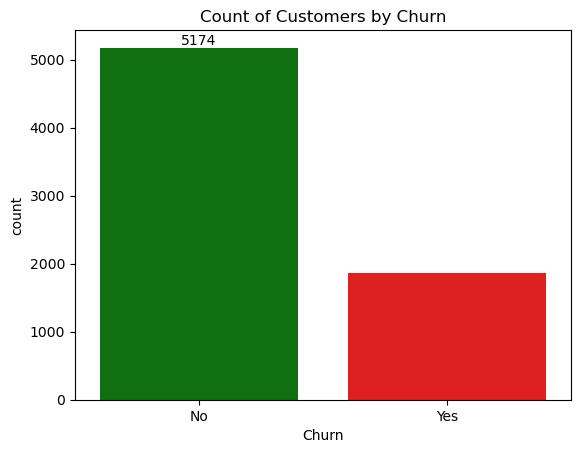

In [17]:
ax = sns.countplot(x="Churn", data=df, palette=["Green", "Red"])
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Churn")
plt.show()

***Insight: Out of 7,043 customers, around 5,174 stayed and 1,869 churned.***

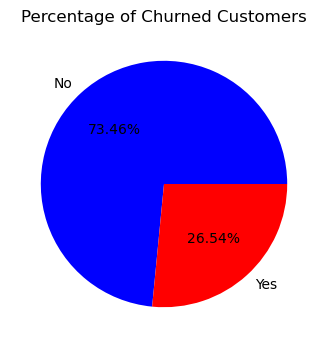

In [18]:
gb = df.groupby("Churn").agg({"Churn": "count"})
plt.figure(figsize=(5, 4))
plt.pie(gb["Churn"], labels=gb.index, autopct="%1.2f%%", colors=["Blue", "Red"])
plt.title("Percentage of Churned Customers")
plt.show()

***Insight: 73.46% customers were retained while 26.54% churned — roughly 1 in 4 customers left.***

 ***9 — Churn by Gender***

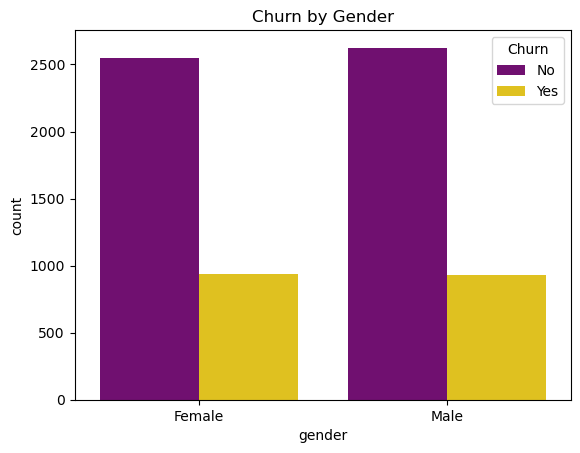

In [19]:
sns.countplot(x="gender", data=df, hue="Churn", palette=["purple", "gold"])
plt.title("Churn by Gender")
plt.show()

***Insight: Male and female customers churn at nearly equal rates. Gender is not a significant churn predictor.***

***10 — Churn by Senior Citizen***

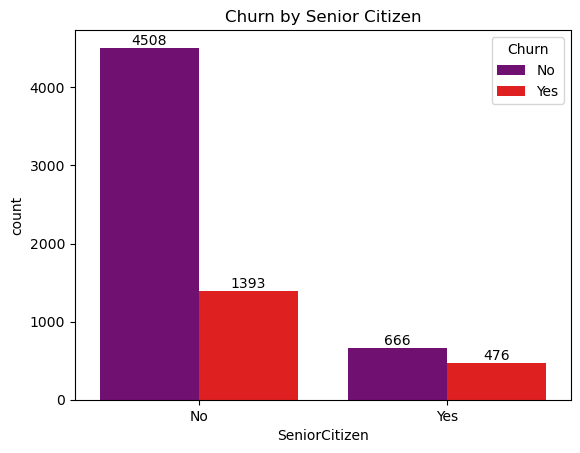

In [20]:
ax = sns.countplot(x="SeniorCitizen", data=df, hue="Churn", palette=["purple", "red"])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churn by Senior Citizen")
plt.show()

***Insight: Senior citizens are a small group but have noticeably higher churn count relative to their size.***

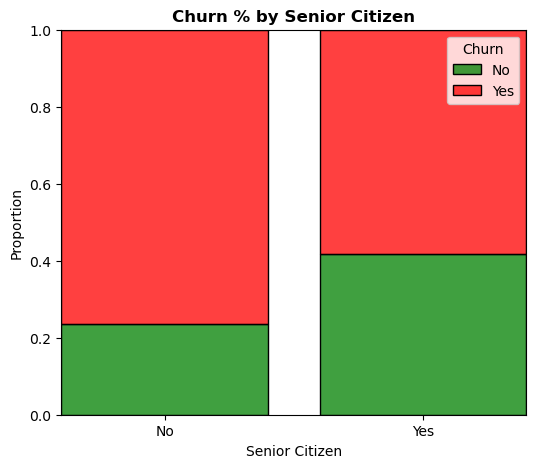

In [21]:
plt.figure(figsize=(6, 5))
sns.histplot(data=df, x="SeniorCitizen", hue="Churn", multiple="fill",
             palette=["red", "green"], shrink=0.8)
plt.title("Churn % by Senior Citizen", fontsize=12, fontweight="bold")
plt.xlabel("Senior Citizen")
plt.ylabel("Proportion")
plt.legend(title="Churn", labels=["No", "Yes"])
plt.show()

***Insight: Senior citizens churn at ~42% vs ~24% for non-seniors. Age is a strong churn factor — seniors need dedicated retention plans.***

***11 — Churn by Tenure***

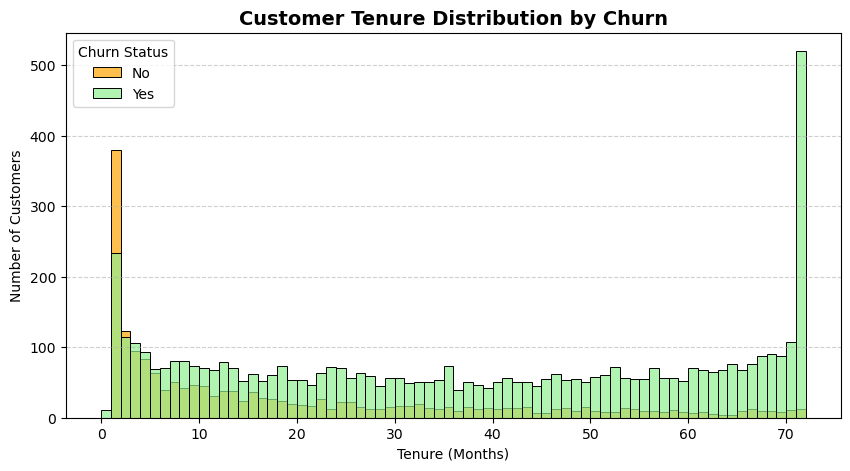

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(x="tenure", data=df, bins=72, hue="Churn",
             palette=["lightgreen", "orange"], alpha=0.7)
plt.title("Customer Tenure Distribution by Churn", fontsize=14, fontweight="bold")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Churn Status", labels=["No", "Yes"])
plt.show()

***Insight: Churn is highest in the first 12 months. Customers who stay beyond 2 years rarely leave — early engagement is critical.***

***12 — Churn by Contract Type***

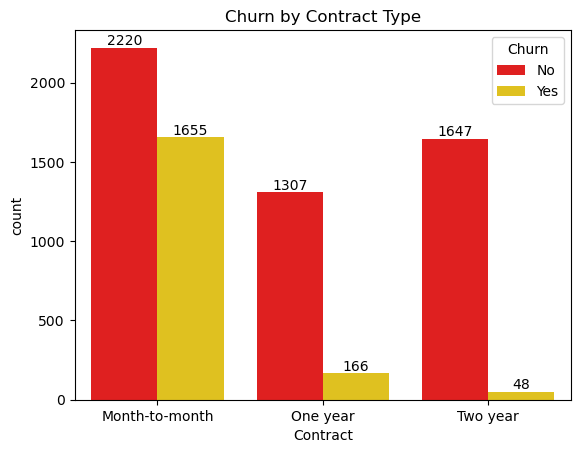

In [23]:
ax = sns.countplot(x="Contract", data=df, hue="Churn", palette=["red", "gold"])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churn by Contract Type")
plt.show()

***Insight: Month-to-month customers churn the most (~43%). One and two year contract customers are far more loyal — long contracts strongly reduce churn.***

***13 — Churn by Payment Method***

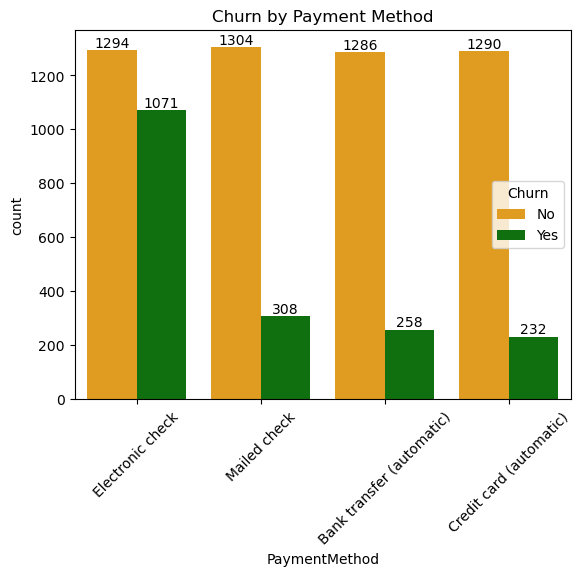

In [24]:
ax = sns.countplot(x="PaymentMethod", data=df, hue="Churn",
                   palette=["orange", "green"])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churn by Payment Method")
plt.xticks(rotation=45)
plt.show()

***Insight: Electronic check users have the highest churn (~45%). Auto-pay users (credit card / bank transfer) churn the least — automatic payments improve retention.***

***14 — Services: Multiple Count Plots***

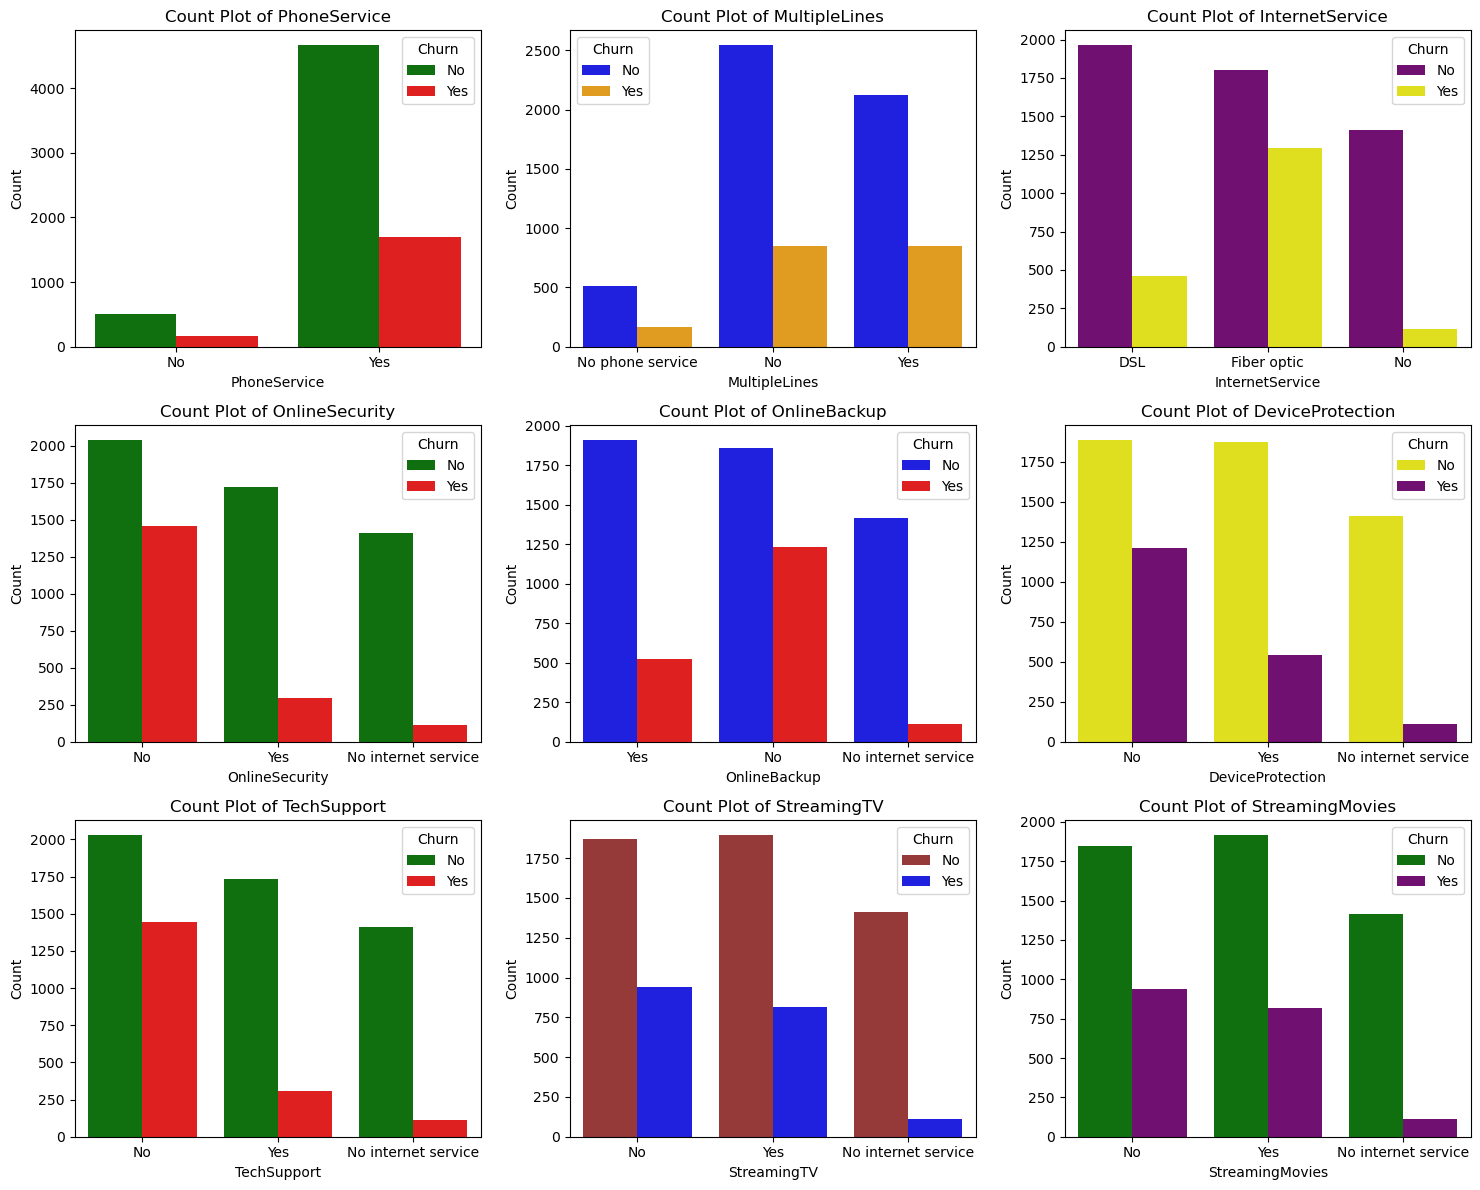

In [25]:
columns = ['PhoneService', 'MultipleLines', 'InternetService',
           'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
           'TechSupport', 'StreamingTV', 'StreamingMovies']

palettes = [
    ["green", "red"],
    ["blue", "orange"],
    ["purple", "yellow"],
    ["green", "red"],
    ["blue", "red"],
    ["yellow", "purple"],
    ["green", "red"],
    ["brown", "blue"],
    ["green", "purple"],
]

n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.countplot(x=col, data=df, ax=axes[i], hue=df["Churn"], palette=palettes[i])
    axes[i].set_title(f"Count Plot of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

***Insight: Customers without Online Security, Tech Support, or using Fiber Optic internet show significantly higher churn. Streaming services show no major churn difference.***

***15 — Correlation Heatmap***

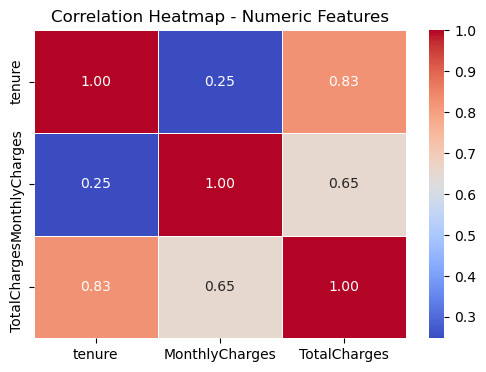

In [26]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap - Numeric Features")
plt.show()

***Insight: Tenure and TotalCharges have strong positive correlation (0.83) — longer customers naturally accumulate higher bills. MonthlyCharges and tenure are weakly correlated.***

***16 — Churn Rate % by Key Features***

In [27]:
print("=== Contract wise Churn Rate ===")
print(df.groupby("Contract")["Churn"].value_counts(normalize=True).mul(100).round(2))

print("\n=== SeniorCitizen wise Churn Rate ===")
print(df.groupby("SeniorCitizen")["Churn"].value_counts(normalize=True).mul(100).round(2))

print("\n=== PaymentMethod wise Churn Rate ===")
print(df.groupby("PaymentMethod")["Churn"].value_counts(normalize=True).mul(100).round(2))

=== Contract wise Churn Rate ===
Contract        Churn
Month-to-month  No       57.29
                Yes      42.71
One year        No       88.73
                Yes      11.27
Two year        No       97.17
                Yes       2.83
Name: proportion, dtype: float64

=== SeniorCitizen wise Churn Rate ===
SeniorCitizen  Churn
No             No       76.39
               Yes      23.61
Yes            No       58.32
               Yes      41.68
Name: proportion, dtype: float64

=== PaymentMethod wise Churn Rate ===
PaymentMethod              Churn
Bank transfer (automatic)  No       83.29
                           Yes      16.71
Credit card (automatic)    No       84.76
                           Yes      15.24
Electronic check           No       54.71
                           Yes      45.29
Mailed check               No       80.89
                           Yes      19.11
Name: proportion, dtype: float64


***Insight: Exact churn percentages confirmed — Month-to-month: ~43%, Senior citizens: ~42%, Electronic check: ~45%. These three are the highest risk groups in the dataset.***

***In my churn analysis project, I started by cleaning the dataset—handling missing values, removing duplicates, and converting numeric fields like SeniorCitizen into categorical labels for better readability. Once the data was prepared, I performed exploratory analysis using Matplotlib and Seaborn. I built visualizations such as count plots, histograms, pie charts, and stacked bar charts to study churn patterns across demographics, tenure, contracts, services, and payment methods. These visual insights revealed which customer groups are more likely to churn, making the dataset ready for predictive modeling and helping businesses design targeted retention strategies."***


***Step 1: Data cleaning***

***Step 2: Visualization & analysis***

***Step 3: Insights & business value***